In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

In [3]:
try:
    url = "https://raw.githubusercontent.com/UBC-MDS/maternal_health_risk_predictor/main/data/maternal_health_risk.csv"
    df = pd.read_csv(url)
    print("✓ Dataset loaded from online source")
except:
    df = pd.read_csv('Maternal Health Risk Data Set.csv')
    print("✓ Dataset loaded from local file")

print(f"Total patients: {len(df)}")
print(f"Total features: {len(df.columns) - 1}")
print()

✓ Dataset loaded from local file
Total patients: 1014
Total features: 6



Dataset Preview:
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk

Dataset Info:
Shape: (1014, 7)
Missing values: 0

Target column: RiskLevel

Class Distribution:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64



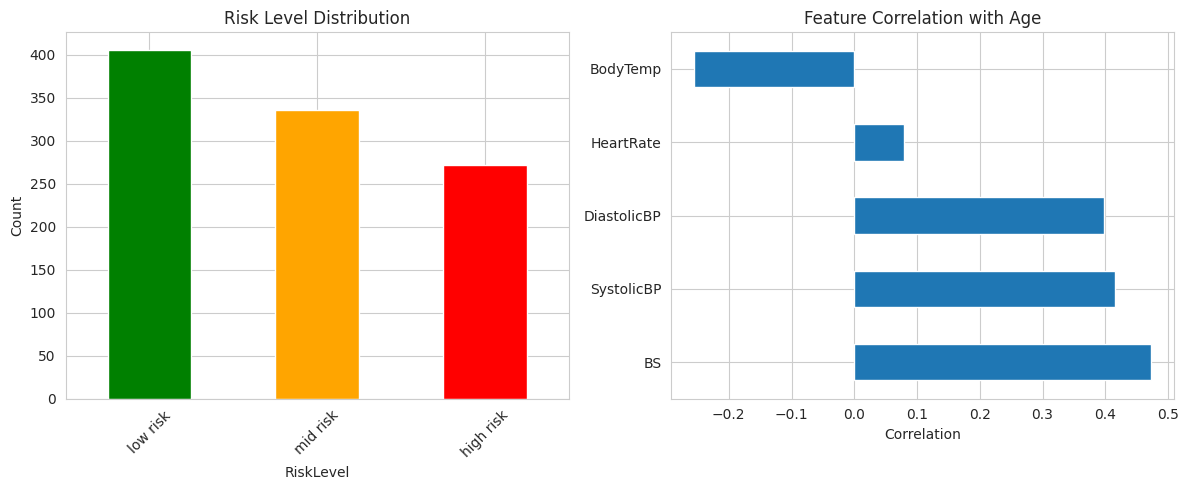

✓ Saved: 01_data_exploration.png



In [5]:
print("Dataset Preview:")
print(df.head())
print()

print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print()

target_col = [col for col in df.columns if 'risk' in col.lower()][0]
print(f"Target column: {target_col}")
print("\nClass Distribution:")
print(df[target_col].value_counts())
print()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[target_col].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Risk Level Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df.select_dtypes(include=[np.number]).corr()['Age'].sort_values(ascending=False)[1:].plot(kind='barh')
plt.title('Feature Correlation with Age')
plt.xlabel('Correlation')

plt.tight_layout()
plt.savefig('01_data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 01_data_exploration.png\n")

In [ ]:
X = df.drop(target_col, axis=1)
y = df[target_col]
print(f"Features: {list(X.columns)}")
print()
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Target Encoding:")
for i, label in enumerate(le.classes_):
    count = np.sum(y_encoded == i)
    print(f"  {label} → {i} ({count} samples, {count/len(y)*100:.1f}%)")
print()
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")
print()

Features: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

Target Encoding:
  high risk → 0 (272 samples, 26.8%)
  low risk → 1 (406 samples, 40.0%)
  mid risk → 2 (336 samples, 33.1%)

Training set: 811 samples
Testing set: 203 samples



In [ ]:
models = {
    'XGBoost': ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                     eval_metric='mlogloss', random_state=42))
    ])
}
results = []
trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"  Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"  CV Accuracy:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Overfitting:    {train_acc - test_acc:.4f}")
    results.append({
        'Model': name,
        'Train_Acc': train_acc,
        'Test_Acc': test_acc,
        'CV_Acc': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Overfit': train_acc - test_acc
    })
    trained_models[name] = model
best_model_name = 'XGBoost'
best_model = trained_models[best_model_name]
print()


Training XGBoost...
  Train Accuracy: 0.8964 (89.64%)
  Test Accuracy:  0.8177 (81.77%)
  CV Accuracy:    0.7768 ± 0.0275
  Overfitting:    0.0787



  Model  Train_Acc  Test_Acc   CV_Acc   CV_Std  Overfit
XGBoost   0.896424  0.817734 0.776816 0.027457  0.07869

✓ MODEL: XGBoost
  Test Accuracy: 81.77%



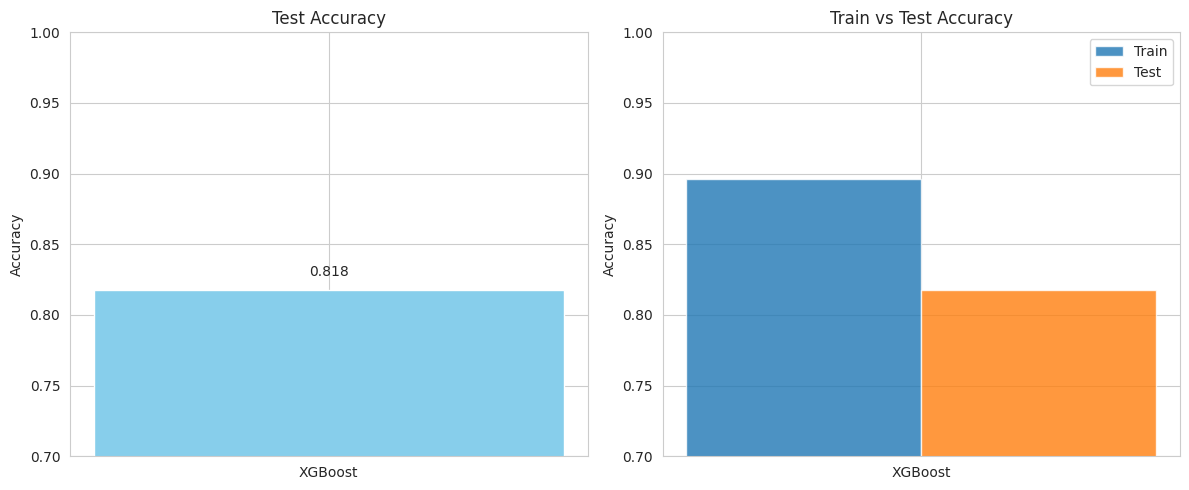

✓ Saved: 02_model_comparison.png



In [ ]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()
print(f"✓ MODEL: {best_model_name}")
print(f"  Test Accuracy: {results_df['Test_Acc'].values[0]*100:.2f}%")
print()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['XGBoost'], results_df['Test_Acc'], color='skyblue', width=0.4)
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.7, 1.0])
axes[0].text(0, results_df['Test_Acc'].values[0] + 0.01,
             f'{results_df["Test_Acc"].values[0]:.3f}', ha='center')
width = 0.35
axes[1].bar(0 - width/2, results_df['Train_Acc'], width, label='Train', alpha=0.8)
axes[1].bar(0 + width/2, results_df['Test_Acc'], width, label='Test', alpha=0.8)
axes[1].set_title('Train vs Test Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks([0])
axes[1].set_xticklabels(['XGBoost'])
axes[1].legend()
axes[1].set_ylim([0.7, 1.0])
plt.tight_layout()
plt.savefig('02_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 02_model_comparison.png\n")


Classification Report:
              precision    recall  f1-score   support

   high risk       0.96      0.87      0.91        55
    low risk       0.86      0.77      0.81        81
    mid risk       0.69      0.84      0.76        67

    accuracy                           0.82       203
   macro avg       0.84      0.82      0.83       203
weighted avg       0.83      0.82      0.82       203


Confusion Matrix:
[[48  1  6]
 [ 0 62 19]
 [ 2  9 56]]



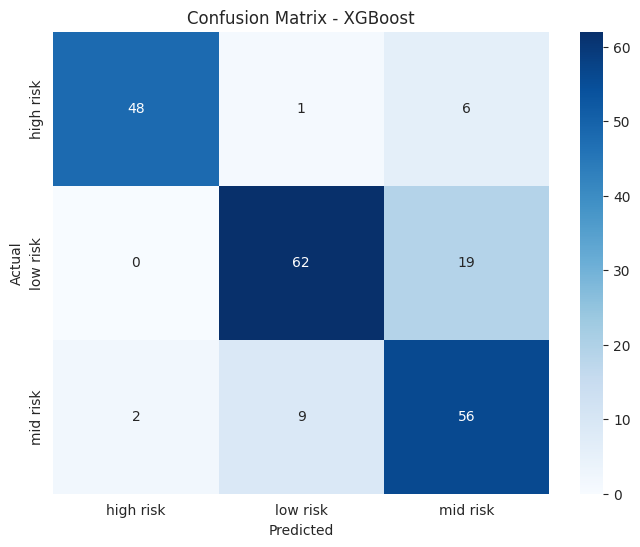

✓ Saved: 03_confusion_matrix.png

Per-Class Performance:
  high risk: 0.8727 (87.27%)
  low risk: 0.7654 (76.54%)
  mid risk: 0.8358 (83.58%)



In [10]:
y_pred = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('03_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_confusion_matrix.png\n")

print("Per-Class Performance:")
for i, class_name in enumerate(le.classes_):
    mask = (y_test == i)
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred[mask])
        print(f"  {class_name}: {acc:.4f} ({acc*100:.2f}%)")
print()


Top Features:
    Feature  Importance
 SystolicBP    0.284125
         BS    0.264321
   BodyTemp    0.222695
        Age    0.090029
DiastolicBP    0.071516
  HeartRate    0.067315



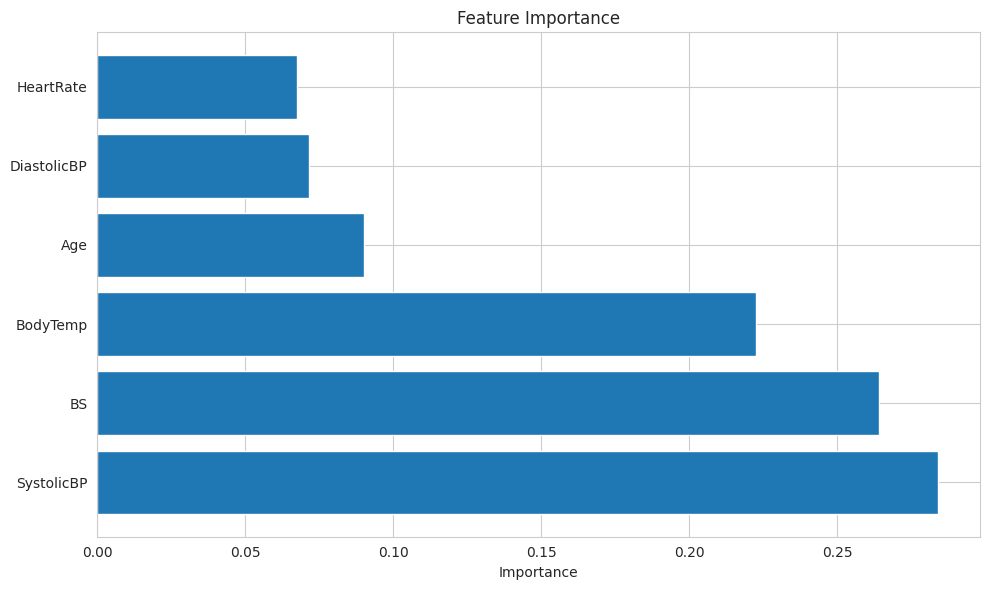

✓ Saved: 04_feature_importance.png



In [ ]:
classifier = best_model.named_steps['classifier']
if hasattr(classifier, 'feature_importances_'):
    importance = classifier.feature_importances_
    feature_imp_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    print("\nTop Features:")
    print(feature_imp_df.to_string(index=False))
    print()
    plt.figure(figsize=(10, 6))
    plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance')
    plt.tight_layout()
    plt.savefig('04_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: 04_feature_importance.png\n")

In [12]:
print("STEP 8: Saving Model")
print("-"*70)

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✓ Saved: best_model.pkl")

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✓ Saved: label_encoder.pkl")

results_df.to_csv('results.csv', index=False)
print("✓ Saved: results.csv")
print()

STEP 8: Saving Model
----------------------------------------------------------------------
✓ Saved: best_model.pkl
✓ Saved: label_encoder.pkl
✓ Saved: results.csv



In [14]:
def predict_risk(age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate):
    """Predict maternal health risk"""

    patient = pd.DataFrame([[age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate]],
                          columns=X.columns)

    pred_encoded = best_model.predict(patient)[0]
    pred_proba = best_model.predict_proba(patient)[0]

    risk_level = le.inverse_transform([pred_encoded])[0]

    print(f"\nInput: Age={age}, BP={systolic_bp}/{diastolic_bp}, BS={blood_sugar}")
    print(f"       Temp={body_temp}°F, HR={heart_rate} bpm")
    print(f"\nPrediction: {risk_level}")
    print(f"\nProbabilities:")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name}: {pred_proba[i]:.2%}")

    return risk_level, pred_proba

print("\nCase 1: Normal Patient")
print("-"*40)
predict_risk(28, 115, 75, 6.5, 98.0, 75)

print("\n\nCase 2: Moderate Risk")
print("-"*40)
predict_risk(35, 140, 90, 8.5, 98.5, 85)

print("\n\nCase 3: High Risk")
print("-"*40)
predict_risk(42, 165, 105, 11.0, 99.0, 95)


Case 1: Normal Patient
----------------------------------------

Input: Age=28, BP=115/75, BS=6.5
       Temp=98.0°F, HR=75 bpm

Prediction: low risk

Probabilities:
  high risk: 0.92%
  low risk: 77.22%
  mid risk: 21.86%


Case 2: Moderate Risk
----------------------------------------

Input: Age=35, BP=140/90, BS=8.5
       Temp=98.5°F, HR=85 bpm

Prediction: high risk

Probabilities:
  high risk: 99.23%
  low risk: 0.07%
  mid risk: 0.70%


Case 3: High Risk
----------------------------------------

Input: Age=42, BP=165/105, BS=11.0
       Temp=99.0°F, HR=95 bpm

Prediction: high risk

Probabilities:
  high risk: 99.72%
  low risk: 0.05%
  mid risk: 0.23%


('high risk',
 array([9.9721330e-01, 5.2348565e-04, 2.2631937e-03], dtype=float32))